# 1.1 Quick start

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/tutorials/1%20Overview/1.1%20Quick%20start.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=tutorials%2F1%20Overview%2F1.1%20Quick%20start.ipynb)

> 💡 **Running in Colab or Binder?** Skip the desktop GUI install — the cell below grabs the lite (no-Qt) wheel, and `qm.gui(design)` auto-picks an inline matplotlib viewer with the same API (`gui.rebuild()`, `gui.screenshot()`, `gui.edit_component(...)`) as the desktop `MetalGUI`.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt).
# Locally you should already have it via `pip install quantum-metal` or
# `pip install 'quantum-metal[gui]'` for the desktop GUI.
# !pip install -q quantum-metal

In [2]:
!pip install "quantum-metal[full]"
!pip install "quantum-metal[gui,ansys]"   # MetalGUI + HFSS/Q3D
!pip install "quantum-metal[gui,mesh]"    # MetalGUI + gmsh
!apt-get update
!apt-get install -y libgl1-mesa-glx libglu1-mesa

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libglu1-mesa is already the newest version (9.0.2-1).
libgl1-mesa-glx is already the newest ve

## Import Qiskit Metal

In [3]:
import qiskit_metal as metal
import qiskit_metal as qm  # alias used by qm.gui / qm.view
from qiskit_metal import designs, draw
from qiskit_metal import Dict, open_docs

%metal_heading Welcome to Qiskit Metal!

## My first Quantum Design (QDesign)

A ``QDesign`` is the canvas that holds your chip components. Start with the planar variant:

```python
design = designs.DesignPlanar()
gui = qm.gui(design)
```

``qm.gui(design)`` is a factory: it returns the desktop ``MetalGUI`` when you have PySide6 and a display, and an inline matplotlib viewer (``MetalGUIHeadless``) otherwise. The same ``gui.*`` API works in both.

Run the cells below to instantiate a design and view it. The chip starts empty — let's add a qubit.

In [4]:
design = designs.DesignPlanar()
gui = qm.gui(design)  # Qt locally, inline matplotlib in Colab/Binder

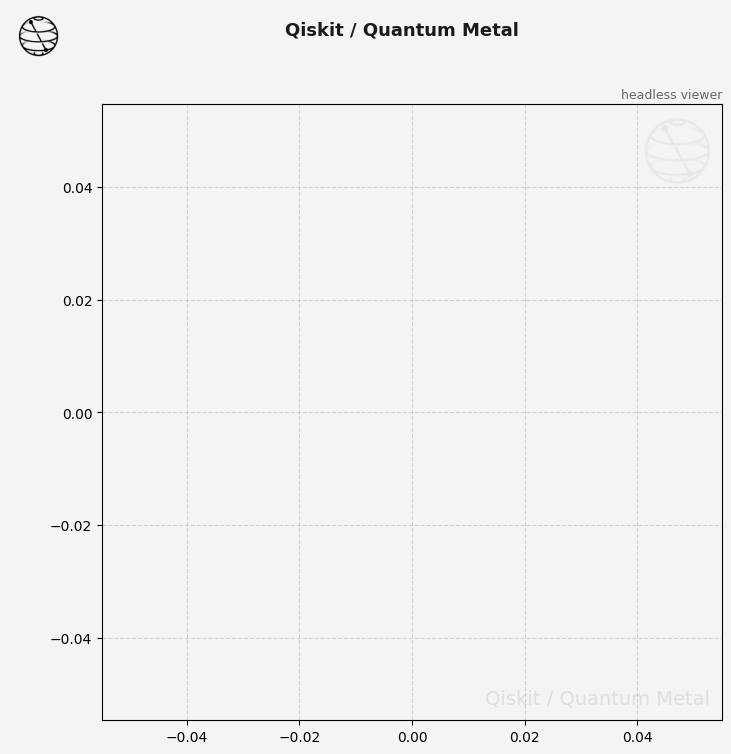

In [5]:
gui.screenshot()

In [6]:
%metal_heading Hello Quantum World!

## My first QComponent — a transmon qubit

Quantum Metal ships a ready-made transmon in ``qiskit_metal.qlibrary.qubits.transmon_pocket``. Adding one is a single line; the GUI refreshes automatically.

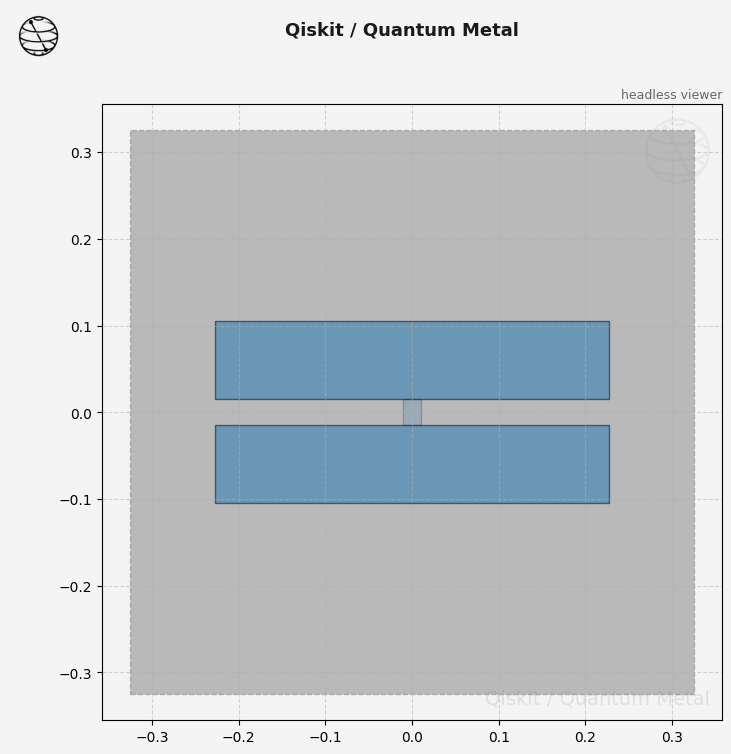

In [7]:
# Select a QComponent to create (The QComponent is a python class named `TransmonPocket`)
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

# Create a new qcomponent object with name 'Q1'
q1 = TransmonPocket(design, "Q1")
gui.rebuild()  # rebuild the design and plot

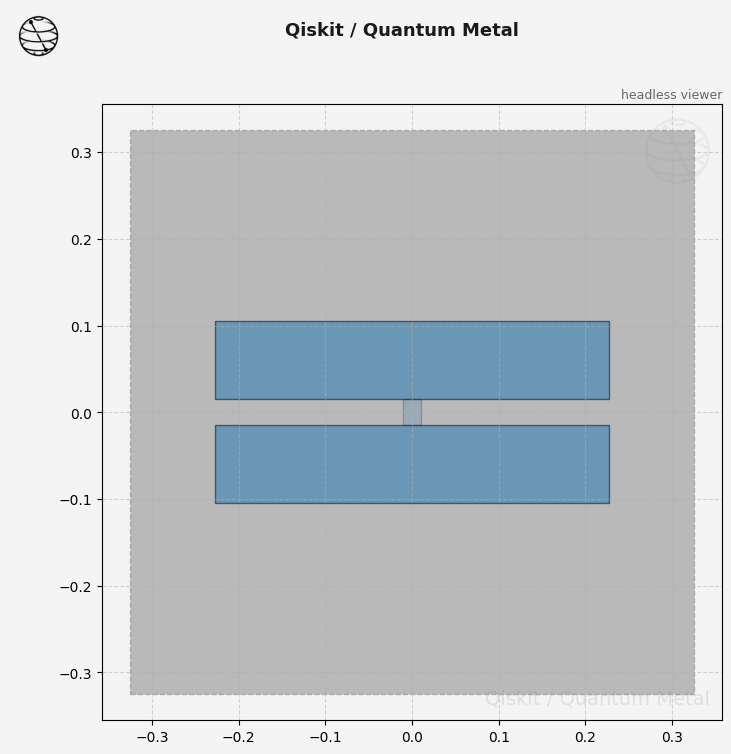

In [8]:
# save screenshot
gui.edit_component("Q1")
gui.autoscale()
gui.screenshot()

Inspect the component we just created:

In [9]:
q1

name:    Q1
class:   TransmonPocket        
options: 
  'pos_x'             : '0.0um',                      
  'pos_y'             : '0.0um',                      
  'orientation'       : '0.0',                        
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'connection_pads'   : {
                        },
  'pad_gap'           : '30um',                       
  'inductor_width'    : '20um',                       
  'pad_width'         : '455um',                      
  'pad_height'        : '90um',                       
  'pocket_width'      : '650um',                      
  'pocket_height'     : '650um',                      
  'hfss_wire_bonds'   : False,                        
  'q3d_wire_bonds'    : False,                        
  'aedt_q3d_wire_bonds': False,                        
  'aedt_hfss_wire_bonds': False,                        
  'hfss_inductance'   : '10nH',                       
  'hfss_ca

### Default options

Every QComponent has a ``default_options`` dictionary. Quantum Metal parses these strings into numeric values during ``rebuild()``. You can change them through the GUI or the Python API — both call the same underlying setters.

In [10]:
%metal_print How do I edit options?  API or GUI

Both paths converge: the GUI just calls the same API you'd write in a notebook.

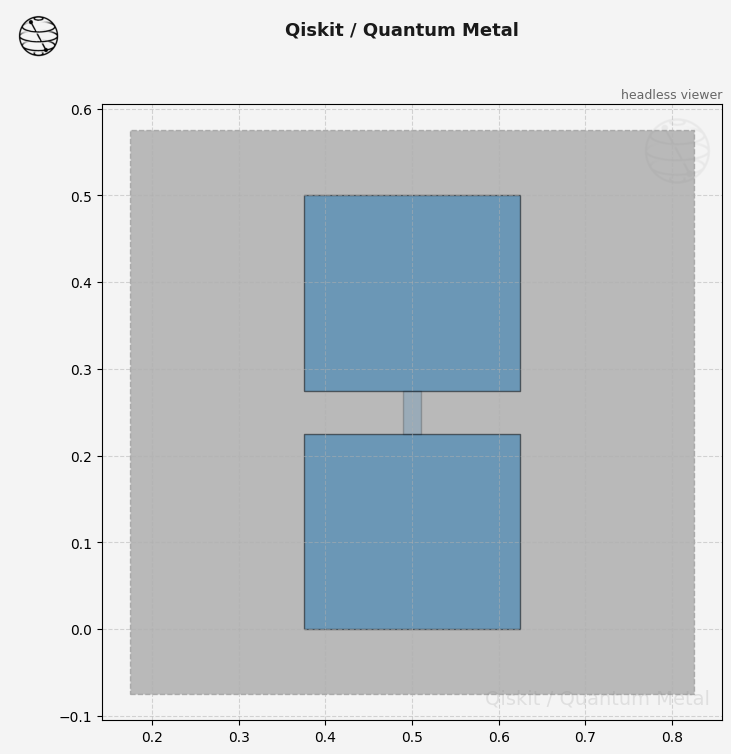

In [11]:
# Change options
q1.options.pos_x = "0.5 mm"
q1.options.pos_y = "0.25 mm"
q1.options.pad_height = "225 um"
q1.options.pad_width = "250 um"
q1.options.pad_gap = "50 um"

# Update the geometry, since we changed the options
gui.rebuild()

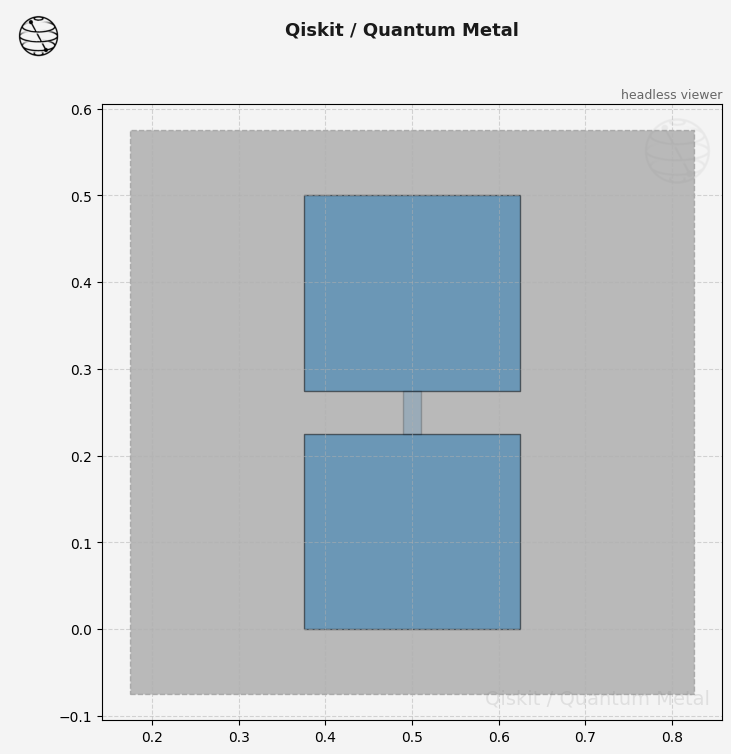

In [12]:
gui.autoscale()
gui.screenshot()

## Compare before and after

Design-as-code means every parameter change is immediate and visual. ``qm.view()`` renders into any matplotlib axes — drop two of them side-by-side to see what changed.

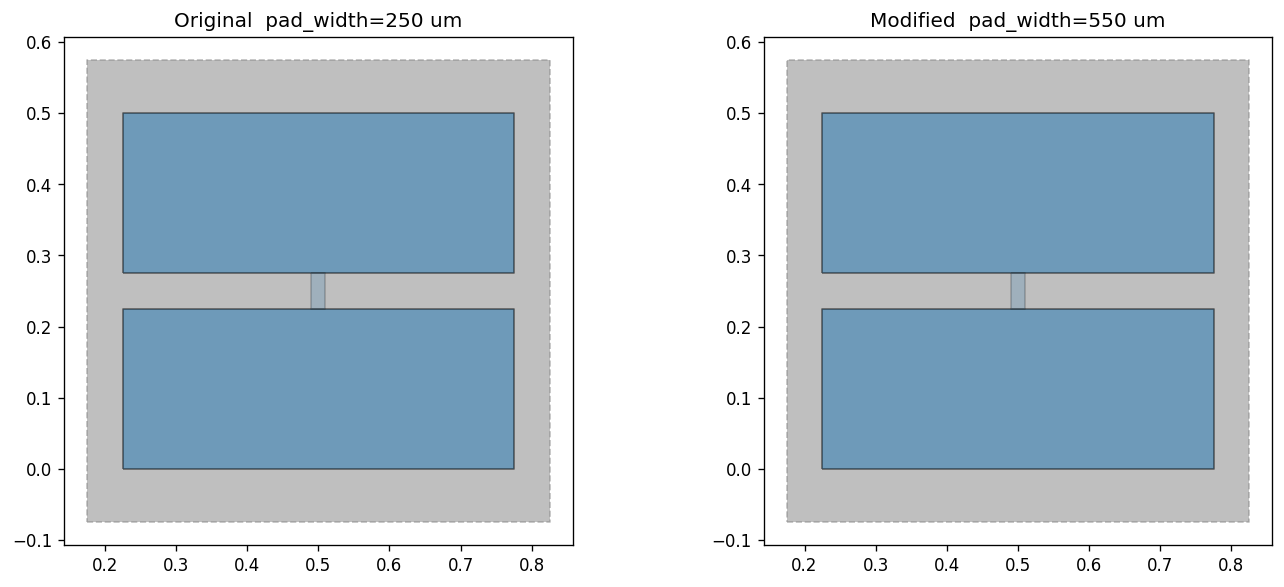

In [13]:
import qiskit_metal as qm
import matplotlib.pyplot as plt

# Record the original value so we can restore it
_orig_pad_width = q1.options.pad_width

# Make a change
q1.options.pad_width = "550 um"
design.rebuild()

# Side-by-side comparison rendered to a PNG so it displays inline in
# Jupyter regardless of which matplotlib backend the GUI activated
# (the desktop MetalGUI sets `QtAgg`, which doesn't render Figures
# directly into notebook cells; ``display(fig)`` falls back to a
# text repr otherwise).
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
qm.view(
    design,
    components=["Q1"],
    title=f"Original  pad_width={_orig_pad_width}",
    ax=axes[0],
)
qm.view(design, components=["Q1"], title="Modified  pad_width=550 um", ax=axes[1])
plt.tight_layout()

import io
from IPython.display import Image, display

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
plt.close(fig)
display(Image(buf.getvalue()))

In [14]:
# Restore the original value before continuing
q1.options.pad_width = _orig_pad_width
design.rebuild()
print(f"Restored pad_width to {q1.options.pad_width}")

Restored pad_width to 250 um


### Where are the QComponents stored?

In ``design.components``. Access by name (``design.components['Q1']``) or attribute (``design.components.Q1``).

In [15]:
q1 = design.components["Q1"]

In [16]:
%metal_print "Where are the default options?"

A QComponent is created with defaults. To inspect them without instantiating one, call ``QComponentClass.get_template_options(design)``.

In [17]:
TransmonPocket.get_template_options(design)

{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 'q3d_resistance': 0,
 'q3d_mesh_kw_jj': 7e-06,
 'gds_cell_name': 'my_other_junction',
 'aedt_q3d_inductance': 1e-08,
 'aedt_q3d_capacitance': 0,
 'aedt_hf

In [18]:
%metal_print How do I change the default options

Two ways to set component options:

- **Instance-level** — ``q1.options.<field> = ...`` changes only ``q1``.
- **Class-level** — ``QComponent.default_options.<field> = ...`` changes the default for every future component instance.

The cell below demonstrates both and restores the class defaults at the end so the rest of the notebook isn't polluted.

In [19]:
# Two different "change the options" patterns:

# 1. Change THIS instance only — what the tutorial has been doing so far.
#    Affects q1, not any future TransmonPocket you create.
q1.options.pos_x = "0.5 mm"
q1.options.pos_y = "250 um"

# 2. Change the CLASS-LEVEL DEFAULTS — affects every TransmonPocket
#    you instantiate after this point. The base ``QComponent.default_options``
#    dict carries ``pos_x``/``pos_y``; component subclasses inherit them.
#    (To change a TransmonPocket-specific default like ``pad_width``,
#    edit ``TransmonPocket.default_options.pad_width`` instead.)
from qiskit_metal.qlibrary.core import QComponent

QComponent.default_options.pos_x = "0.5 mm"
QComponent.default_options.pos_y = "250 um"

# Rebuild for changes to propagate
gui.rebuild()

# Reset class defaults so the rest of the notebook doesn't see them.
QComponent.default_options.pos_x = "0.0um"
QComponent.default_options.pos_y = "0.0um"

In [20]:
%metal_print How do I work with units? <br><br> (parse options and values)

### Parsing strings into floats

Quantum Metal accepts options as strings with units (``"250 um"``, ``"0.5 mm"``). Use ``design.parse_value`` or any component's ``.parse_value`` to convert.

In [21]:
print("Design default units for length: ", design.get_units())
print(
    "\nExample 250 micron parsed to design units:",
    design.parse_value("250 um"),
    design.get_units(),
)

dictionary = {"key_in_cm": "1.2 cm", "key_in_microns": "50 um"}
print("\nExample parse dict:", design.parse_value(dictionary))

a_list = ["1m", "1mm", "1um", "1 nm"]
print("\nExample parse list:", design.parse_value(a_list))

Design default units for length:  mm

Example 250 micron parsed to design units: 0.25 mm

Example parse dict: {'key_in_cm': 12.0, 'key_in_microns': 0.05}

Example parse list: [1000.0, 1, 0.001, 1.0000000000000002e-06]


### Arithmetic in option strings

In [22]:
design.parse_value("2 * 2um")

0.004

In [23]:
design.parse_value("2um + 5um")

0.007

In [24]:
design.qgeometry.tables["junction"]

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (0.5 0.225, 0.5 0.275)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


In [25]:
%metal_heading The geometry of QComponent: QGeometry

### Bounding box

``q1.qgeometry_bounds()`` returns ``(xmin, ymin, xmax, ymax)`` for the component's geometry.

In [26]:
for name, qcomponent in design.components.items():
    print(f"{name:10s} : {qcomponent.qgeometry_bounds()}")

Q1         : [ 0.175 -0.075  0.825  0.575]


### What is QGeometry?

Each QComponent contributes one or more shapely geometries to the design. They're grouped by kind — ``poly``, ``path``, ``junction`` — accessible via ``qgeometry_table(kind)``.

In [27]:
q1.qgeometry_table("poly")

,component,name,geometry,layer,subtract,helper,chip,fillet
0,1,pad_top,"POLYGON ((0.375 0.275, 0.625 0.275, 0.625 0.5,...",1,False,False,main,NaN
1,1,pad_bot,"POLYGON ((0.375 0, 0.625 0, 0.625 0.225, 0.375...",1,False,False,main,NaN
2,1,rect_pk,"POLYGON ((0.175 -0.075, 0.825 -0.075, 0.825 0....",1,True,False,main,NaN


``path`` geometries are lines with a width:

In [28]:
q1.qgeometry_table("path")

,component,name,geometry,layer,subtract,helper,chip,width,fillet,hfss_wire_bonds,q3d_wire_bonds,aedt_q3d_wire_bonds,aedt_hfss_wire_bonds


``junction`` geometries hold Josephson-junction placement, defined by a ``LineString`` and a width.

In [29]:
q1.qgeometry_table("junction")

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (0.5 0.225, 0.5 0.275)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


### Advanced — arrays and expressions

Option strings support pythonic ``ast.literal_eval`` — you can embed lists, tuples, and arithmetic, all parsed lazily.

In [30]:
#### List
print("* " * 10 + " LIST " + "* " * 10, "\n")
str_in = "[1,2,3,'10um']"
out = design.parse_value(str_in)
print(f"Parsed output:\n {str_in}  ->  {out} \n Out type: {type(out)}\n")

str_in = "['2*2um', '2um + 5um']"
out = design.parse_value(str_in)
print(f"Parsed output:\n {str_in}  ->  {out} \n Out type: {type(out)}\n")

#### Dict
print("* " * 10 + " DICT " + "* " * 10, "\n")

str_in = "{'key1': '100um', 'key2': '1m'}"
out = design.parse_value(str_in)
print(f"Parsed output:\n {str_in}  ->  {out} \n Out type: {type(out)}\n")

* * * * * * * * * *  LIST * * * * * * * * * *  

Parsed output:
 [1,2,3,'10um']  ->  [1, 2, 3, 0.01] 
 Out type: <class 'list'>

Parsed output:
 ['2*2um', '2um + 5um']  ->  [0.004, 0.007] 
 Out type: <class 'list'>

* * * * * * * * * *  DICT * * * * * * * * * *  

Parsed output:
 {'key1': '100um', 'key2': '1m'}  ->  {'key1': 0.1, 'key2': 1000.0} 
 Out type: <class 'addict.addict.Dict'>



## Overwriting components

By default, instantiating a component with an existing name raises. Enable overwrite for repeatable demos:

In [31]:
design.overwrite_enabled = True

In [32]:
%metal_heading Quantum pins: QPins!

### QPins — the dynamic way to connect components

A component designer can expose ``QPin`` endpoints. Pins let components link up: two transmons each expose a pin, a ``RouteMeander`` connects them into a CPW. Below, we recreate ``Q1`` with named connection pads.

In [33]:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

design.delete_all_components()

options = dict(
    pad_width="425 um",
    pocket_height="650um",
    connection_pads=dict(  # pin connectors
        a=dict(loc_W=+1, loc_H=+1),
        b=dict(loc_W=-1, loc_H=+1, pad_height="30um"),
        c=dict(loc_W=+1, loc_H=-1, pad_width="200um"),
        d=dict(loc_W=-1, loc_H=-1, pad_height="50um"),
    ),
)

q1 = TransmonPocket(
    design, "Q1", options=dict(pos_x="+0.5mm", pos_y="+0.5mm", **options)
)

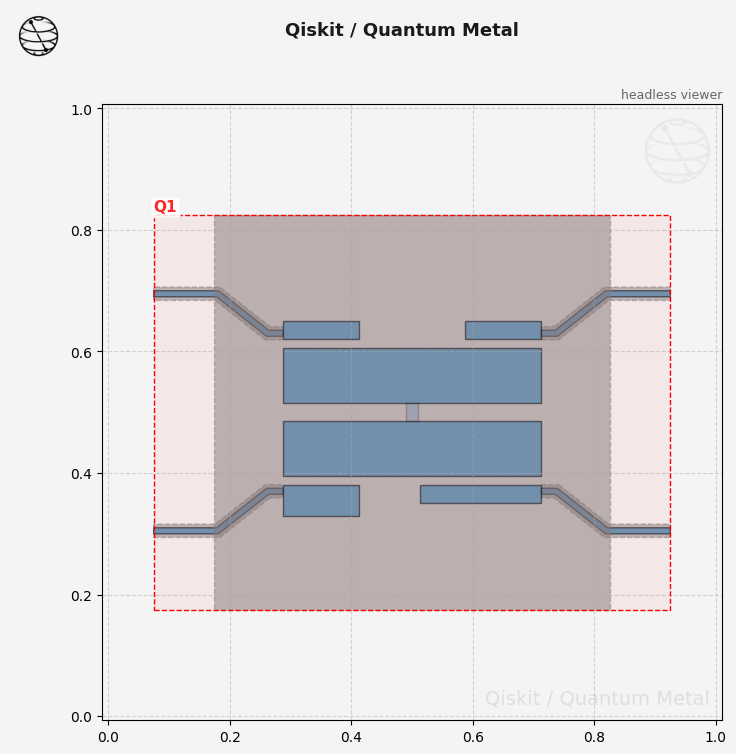

In [34]:
# Take a screenshot with the component highlighted and the pins shown
gui.rebuild()
gui.autoscale()
gui.edit_component("Q1")
gui.zoom_on_components(["Q1"])
gui.highlight_components(["Q1"])
gui.screenshot()

Access a pin by name:

In [35]:
q1.pins.a
q1.pins["a"]

{'points': [array([0.925, 0.7  ]), array([0.925, 0.69 ])],
 'middle': array([0.925, 0.695]),
 'normal': array([1., 0.]),
 'tangent': array([0., 1.]),
 'width': 0.01,
 'gap': 0.006,
 'chip': 'main',
 'parent_name': 2,
 'net_id': 0,
 'length': 0}

### Editing component source from the API

``gui.edit_component("Q1")`` opens the Qt source editor in the desktop GUI. In the headless viewer it's a no-op — edit the source file directly and call ``gui.rebuild()``.

In [36]:
gui.edit_component("Q1")

---

## What's next?

You've placed a transmon, modified it, compared variants, connected two qubits with a CPW, and inspected geometry. Plenty for one tutorial.

- **Want the concepts?** [1.2 Bird's eye view](./1.2-Bird's-eye-view-of-Quantum-Metal.ipynb) — what is a QDesign / QComponent / QRenderer, with diagrams.
- **Build the full chip:** [1.3 Build a 4-qubit chip](./1.3-Build-a-4-qubit-chip.ipynb) — ring layout, CPW routing, design variables.
- **Save & export:** [1.4 Saving & exporting](./1.4-Saving-Your-Chip-Design.ipynb) — `to_python_script()` + GDS for fabrication.
- **Browse every component:** [QComponent Gallery](../../qcomponents-gallery.rst) — visual catalog of every qubit, coupler, route, resonator, and termination.
